# Machine Learning per l'Analisi Finanziaria

## Lezione 05 — Modellazione Avanzata e Simulazione di Progetto

**Authors:**
- Enrico Huber
- Pietro Soglia

**Last updated:** 2026-05-13

## Obiettivi di apprendimento

- Utilizzare la **cross-validation** per stimare la variabilità delle
  performance e validare la robustezza delle stime ottenute in L3.
- Effettuare **hyperparameter tuning** sistematico con RandomizedSearchCV
  su Random Forest e XGBoost.
- Introdurre **XGBoost** come modello di gradient boosting e confrontarlo
  empiricamente con il Random Forest.
- Selezionare il **modello finale** con giustificazione data-driven rigorosa.
- Comprendere i **cenni MLOps** per la messa in produzione.

## Approccio metodologico

Questa lezione segue il ciclo di ragionamento di un Data Scientist reale:

> **Ipotesi → Esperimento → Osservazione → Decisione → Prossima ipotesi**

Non conosciamo a priori cosa troveremo. Ogni decisione è **data-driven**:
prima osserviamo i risultati, poi decidiamo il passo successivo.
Conserviamo anche le sperimentazioni che non portano dove atteso —
dagli errori si impara.

## Outline

### BLOCCO A — Riapertura e baseline rigorosa
1. Setup, percorsi e costanti
2. Recap Lezione 4 e domanda motrice

### BLOCCO B — Cross-Validation: quanto è affidabile il nostro RF?
3. Perché serve la cross-validation
4. StratifiedKFold sul RF baseline (k=5)
5. Cross-validation con più metriche

### BLOCCO C — Hyperparameter Tuning del Random Forest
6. Definire lo spazio di ricerca RF
7. RandomizedSearchCV sul Random Forest
8. Analisi dei risultati del tuning RF
9. Valutazione RF tunato sul validation set

### BLOCCO D — Introduzione a XGBoost
10. Cos'è il Gradient Boosting? Intuizione e differenze col RF
11. XGBoost baseline — primo fit senza tuning
12. XGBoost baseline — metriche complete e confronto

### BLOCCO E — Hyperparameter Tuning di XGBoost
13. Spazio di ricerca XGBoost
14. RandomizedSearchCV su XGBoost
15. Analisi del tuning XGBoost e confronto globale

### BLOCCO F — Sperimentazione: feature selection + ensemble
16. Ipotesi: le top-K feature (SHAP) migliorano XGBoost?
17. Esperimento: XGBoost tunato con K=10 e K=15 feature
18. Stacking/Voting come esperimento esplorativo

### BLOCCO G — Selezione del modello finale
19. Tabella riepilogativa: tutti i candidati
20. Scelta del modello finale — ragionamento data-driven
21. Valutazione FINALE sul Test Set

### BLOCCO H — Cenni MLOps
22. Cenni MLOps: dalla sperimentazione alla produzione
23. Domande guidate
24. Chiusura del percorso: dall'EDA al modello in produzione

---
## BLOCCO A — Riapertura e baseline rigorosa

---

## 1. Setup, percorsi e costanti

Carichiamo i dati preprocessati dalla Lezione 2, il modello RF dalla
Lezione 3 e gli artefatti di interpretabilità dalla Lezione 4.
L'obiettivo è ripartire con un quadro completo di dove siamo arrivati.

In [65]:
from __future__ import annotations

import json
import random
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
)
from xgboost import XGBClassifier

try:
    from IPython.display import display  # type: ignore
except Exception:  # pragma: no cover

    def display(x):  # type: ignore
        """Fallback display per esecuzione fuori da Jupyter."""
        print(x)


warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)


def resolve_project_root() -> Path:
    """Risolve la root del repository indipendentemente dalla cwd."""
    start_points = [Path.cwd().resolve()]
    if "__file__" in globals():
        start_points.append(Path(__file__).resolve().parent)
    for start in start_points:
        for candidate in [start, *start.parents]:
            if (candidate / "data" / "archive.zip").exists() and (
                candidate / "notebooks"
            ).exists():
                return candidate
    raise FileNotFoundError(
        "Impossibile determinare la root del progetto. "
        "Atteso un percorso contenente data/archive.zip e notebooks/."
    )


ROOT = resolve_project_root()
DATA_OUT_DIR = ROOT / "outputs" / "data"
FIGURES_DIR = ROOT / "outputs" / "figures"
MODELS_DIR = DATA_OUT_DIR

for _dir in [DATA_OUT_DIR, FIGURES_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")


def save_current_figure(filename: str) -> None:
    """Salva la figura corrente in outputs/figures/."""
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=120, bbox_inches="tight")
    print(f"Figura salvata: {FIGURES_DIR / filename}")


def load_preprocessed_split(
    prefix: str,
) -> tuple[np.ndarray, np.ndarray]:
    """Carica X e y da parquet per uno split (train, val o test).

    Parameters
    ----------
    prefix : str
        Uno tra 'train', 'val', 'test'.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Coppia (X, y) come array numpy.
    """
    x_path = DATA_OUT_DIR / f"lesson_02_X_{prefix}.parquet"
    y_path = DATA_OUT_DIR / f"lesson_02_y_{prefix}.parquet"
    for p in [x_path, y_path]:
        if not p.exists():
            raise FileNotFoundError(
                f"File non trovato: {p}\n" "Esegui prima il notebook della Lezione 2."
            )
    X = pd.read_parquet(x_path).values
    y = pd.read_parquet(y_path).squeeze().values
    return X, y

In [66]:
# --- Caricamento dati preprocessati dalla Lezione 2 ---
X_train, y_train = load_preprocessed_split("train")
X_val, y_val = load_preprocessed_split("val")
X_test, y_test = load_preprocessed_split("test")

with open(DATA_OUT_DIR / "lesson_02_feature_names.json") as fh:
    feature_names = json.load(fh)

print(f"Feature totali: {len(feature_names)}")
print(f"\n{'Split':<8} {'Shape X':<18} {'N churn':<12} {'Churn rate'}")
print("-" * 56)
for name, X, y in [
    ("train", X_train, y_train),
    ("val", X_val, y_val),
    ("test", X_test, y_test),
]:
    print(f"{name:<8} {str(X.shape):<18} {y.sum():<12.0f} {y.mean():.4f}")

Feature totali: 30

Split    Shape X            N churn      Churn rate
--------------------------------------------------------
train    (6000, 30)         1223         0.2038
val      (2000, 30)         408          0.2040
test     (2000, 30)         407          0.2035


In [67]:
# --- Caricamento modello RF dalla Lezione 3 ---
model_path = DATA_OUT_DIR / "lesson_03_best_model.pkl"
if not model_path.exists():
    raise FileNotFoundError(
        f"Modello non trovato: {model_path}\n"
        "Esegui prima il notebook della Lezione 3."
    )
rf_baseline = joblib.load(model_path)
print(f"Modello caricato: {rf_baseline}")

Modello caricato: RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)


In [68]:
# --- Caricamento artefatti dalla Lezione 4 ---
with open(DATA_OUT_DIR / "lesson_04_feature_ranking.json") as fh:
    feature_ranking_l4 = json.load(fh)

with open(DATA_OUT_DIR / "lesson_03_metrics.json") as fh:
    metrics_l3 = json.load(fh)

print("Metriche L3 (baseline):")
print(json.dumps(metrics_l3, indent=2))

Metriche L3 (baseline):
{
  "best_model": "RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)",
  "best_threshold": 0.36,
  "train": {
    "accuracy": 1.0,
    "precision": 1.0,
    "recall": 1.0,
    "f1": 1.0,
    "roc_auc": 1.0
  },
  "val": {
    "accuracy": 0.8645,
    "precision": 0.6846,
    "recall": 0.6225,
    "f1": 0.6521,
    "roc_auc": 0.8723
  },
  "test": {
    "accuracy": 0.843,
    "precision": 0.6195,
    "recall": 0.5921,
    "f1": 0.6055,
    "roc_auc": 0.8575
  }
}


## 2. Recap Lezione 4 e domanda motrice

Nella Lezione 3 abbiamo addestrato un Random Forest con
`n_estimators=200` e `class_weight='balanced'` raggiungendo:

| Metrica | Validation | Test |
|---------|-----------|------|
| ROC-AUC | 0.872 | 0.858 |
| F1 | 0.652 | 0.606 |
| Recall | 0.623 | 0.592 |
| Precision | 0.685 | 0.620 |

Nella Lezione 4 abbiamo scoperto che le feature più importanti (SHAP)
sono: **Age**, **NumOfProducts_2**, **Balance**, **Geography_Germany**
e **IsActiveMember_1**.

**Problemi aperti:**
1. Il train AUC = 1.0 → **overfitting palese** del RF
2. La stima AUC = 0.872 si basa su **un singolo split** → quanto è affidabile?
3. Iperparametri mai ottimizzati (n_estimators=200, nessun max_depth)
4. Non abbiamo provato modelli potenzialmente superiori (XGBoost)

**Domanda motrice:**
> Il nostro RF ha AUC=0.872 su un singolo split con overfitting totale
> (train AUC=1.0). **Quanto è affidabile questa stima? Possiamo fare meglio?**

---
## BLOCCO B — Cross-Validation: quanto è affidabile il nostro RF?

---

## 3. Perché serve la cross-validation

Finora abbiamo valutato il modello su un singolo split di validazione.
Ma un singolo split può essere "fortunato" o "sfortunato" — la stima
puntuale AUC=0.872 non ci dice nulla sulla **variabilità**.

La **Stratified K-Fold Cross-Validation** ci permette di:
- Stimare media e deviazione standard dell'AUC su K split diversi
- Verificare se il modello è **stabile** o se la performance oscilla
- Ottenere una stima più robusta della performance attesa

Usiamo `StratifiedKFold` che preserva il rapporto di classe (80/20) in
ogni fold — cruciale con classi sbilanciate.

**Nota importante:** la cross-validation la eseguiamo **solo su X_train**.
Il test set resta intoccato fino alla valutazione finale (Sezione 21).

In [69]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("StratifiedKFold configurato:")
print(f"  - n_splits: 5")
print(f"  - shuffle: True")
print(f"  - random_state: {SEED}")
print(f"  - Campioni per fold (train): ~{int(len(y_train) * 4/5)}")
print(f"  - Campioni per fold (val): ~{int(len(y_train) * 1/5)}")

StratifiedKFold configurato:
  - n_splits: 5
  - shuffle: True
  - random_state: 42
  - Campioni per fold (train): ~4800
  - Campioni per fold (val): ~1200


## 4. StratifiedKFold sul RF baseline (k=5)

Verifichiamo se la stima puntuale AUC=0.872 è rappresentativa o se
c'è alta variabilità tra fold diversi.

In [70]:
cv_auc_baseline = cross_val_score(
    rf_baseline, X_train, y_train, cv=skf, scoring="roc_auc"
)

print("Cross-validation ROC-AUC (RF baseline, 5-fold):")
print("-" * 45)
for i, score in enumerate(cv_auc_baseline, 1):
    print(f"  Fold {i}: {score:.4f}")
print("-" * 45)
print(f"  Media:  {cv_auc_baseline.mean():.4f}")
print(f"  Std:    {cv_auc_baseline.std():.4f}")
print(f"  Range:  [{cv_auc_baseline.min():.4f}, {cv_auc_baseline.max():.4f}]")

Cross-validation ROC-AUC (RF baseline, 5-fold):
---------------------------------------------
  Fold 1: 0.8647
  Fold 2: 0.8365
  Fold 3: 0.8318
  Fold 4: 0.8525
  Fold 5: 0.8504
---------------------------------------------
  Media:  0.8472
  Std:    0.0118
  Range:  [0.8318, 0.8647]


### Interpretazione

La cross-validation svela un quadro diverso dalla stima puntuale:
- La media CV (0.847) è **inferiore** alla stima su singolo val split (0.872).
  Questo significa che il val split era leggermente "fortunato" — la CV dà una
  stima più conservativa ma più affidabile.
- La std (0.012) indica variabilità moderata: il modello non è instabile ma
  la performance fluttua di circa ±1.2 punti percentuali tra fold.
- L'intervallo [0.832, 0.865] ci dice che in uno scenario pessimistico
  scendiamo sotto 0.84.

**Lezione:** non fidarsi mai di un singolo split. La CV è la stima
da riportare. Procediamo a verificare anche F1 e Recall.

## 5. Cross-validation con più metriche

L'AUC non è l'unica metrica rilevante. Verifichiamo che anche
F1 e Recall (cruciali nel contesto bancario) siano stabili.

In [71]:
scoring_dict = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
}

cv_results_baseline = cross_validate(
    rf_baseline, X_train, y_train, cv=skf, scoring=scoring_dict, return_train_score=True
)

print("Cross-validation multi-metrica (RF baseline, 5-fold):")
print("=" * 60)
print(f"{'Metrica':<12} {'Media ± Std (val)':<22} {'Media train'}")
print("-" * 60)
for metric in ["roc_auc", "f1", "recall", "precision"]:
    val_scores = cv_results_baseline[f"test_{metric}"]
    train_scores = cv_results_baseline[f"train_{metric}"]
    print(
        f"{metric:<12} "
        f"{val_scores.mean():.4f} ± {val_scores.std():.4f}    "
        f"{train_scores.mean():.4f}"
    )
print("-" * 60)
print(
    "\nGap train-val (AUC): "
    f"{cv_results_baseline['train_roc_auc'].mean():.4f} - "
    f"{cv_results_baseline['test_roc_auc'].mean():.4f} = "
    f"{cv_results_baseline['train_roc_auc'].mean() - cv_results_baseline['test_roc_auc'].mean():.4f}"
)

Cross-validation multi-metrica (RF baseline, 5-fold):
Metrica      Media ± Std (val)      Media train
------------------------------------------------------------
roc_auc      0.8472 ± 0.0118    1.0000
f1           0.5339 ± 0.0438    1.0000
recall       0.4055 ± 0.0340    1.0000
precision    0.7833 ± 0.0738    1.0000
------------------------------------------------------------

Gap train-val (AUC): 1.0000 - 0.8472 = 0.1528


### Interpretazione

I numeri confermano l'overfitting massiccio:
- Train AUC = 1.0000 (perfetto!) vs Val AUC = 0.847 → **gap = 0.153**
- Train Recall = 1.0, Train F1 = 1.0 → il modello memorizza il train set
- Val Recall = 0.406 con std = 0.034 → instabile e basso
- Val F1 = 0.534 → il modello in CV è decisamente peggiore di quanto
  il singolo val split (F1=0.652) ci faceva credere

**Decisione emergente:** il tuning deve mirare a **ridurre l'overfitting**
(limitando max_depth, aumentando min_samples_leaf) piuttosto che
ad aumentare la complessità del modello. Il gap di 0.15 è inaccettabile.

---
## BLOCCO C — Hyperparameter Tuning del Random Forest

---

## 6. Definire lo spazio di ricerca RF

Il RF attuale ha train AUC = 1.0 — segno che ogni albero cresce senza
limiti e memorizza i dati. Dobbiamo introdurre **regolarizzazione**:

| Parametro | Default attuale | Effetto |
|-----------|----------------|---------|
| `max_depth` | None (illimitato) | Limita la profondità → meno overfitting |
| `min_samples_split` | 2 | Soglia minima per split → alberi meno specifici |
| `min_samples_leaf` | 1 | Minimo campioni per foglia → meno rumore |
| `max_features` | 'sqrt' | N. feature considerate per split |
| `n_estimators` | 200 | Più alberi = più stabile (ma rallenta) |
| `class_weight` | 'balanced' | Gestione imbalance (lo manteniamo) |

Usiamo **RandomizedSearchCV** (non GridSearchCV): è più efficiente
per spazi ampi perché esplora combinazioni casuali anziché l'intero
prodotto cartesiano.

In [72]:
param_distributions_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 8, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.3, 0.5],
    "class_weight": ["balanced", "balanced_subsample"],
}

n_combinations = 1
for v in param_distributions_rf.values():
    n_combinations *= len(v)

print(f"Combinazioni totali nello spazio: {n_combinations:,}")
print(f"Ne esploreremo 50 con RandomizedSearchCV (5-fold)")
print(f"Fit totali: 50 × 5 = 250")

Combinazioni totali nello spazio: 3,072
Ne esploreremo 50 con RandomizedSearchCV (5-fold)
Fit totali: 50 × 5 = 250


## 7. RandomizedSearchCV sul Random Forest

Lanciamo la ricerca. Ogni combinazione viene valutata con 5-fold
Stratified CV sull'AUC. Al termine avremo la migliore combinazione
trovata e potremo confrontarla con il baseline.

In [73]:
random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=SEED),
    param_distributions=param_distributions_rf,
    n_iter=50,
    cv=skf,
    scoring="roc_auc",
    random_state=SEED,
    n_jobs=-1,
    verbose=0,
    return_train_score=True,
)

print("Avvio RandomizedSearchCV per Random Forest...")
random_search_rf.fit(X_train, y_train)
print("Ricerca completata!")
print(f"\nMigliori iperparametri trovati:")
for param, value in random_search_rf.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV AUC: {random_search_rf.best_score_:.4f}")
print(f"Baseline CV AUC: {cv_auc_baseline.mean():.4f}")
print(
    f"Miglioramento: " f"{random_search_rf.best_score_ - cv_auc_baseline.mean():+.4f}"
)

Avvio RandomizedSearchCV per Random Forest...
Ricerca completata!

Migliori iperparametri trovati:
  n_estimators: 500
  min_samples_split: 20
  min_samples_leaf: 2
  max_features: sqrt
  max_depth: 20
  class_weight: balanced_subsample

Best CV AUC: 0.8528
Baseline CV AUC: 0.8472
Miglioramento: +0.0057


## 8. Analisi dei risultati del tuning RF

Analizziamo come i singoli iperparametri influenzano la performance.
In particolare vogliamo capire se il `max_depth` limitato ha ridotto
l'overfitting.

In [74]:
cv_results_rf = pd.DataFrame(random_search_rf.cv_results_)

# Top-10 combinazioni
top10_rf = cv_results_rf.nsmallest(10, "rank_test_score")[
    ["params", "mean_test_score", "std_test_score", "mean_train_score"]
].reset_index(drop=True)

print("Top-10 combinazioni (RF tuning):")
print("=" * 70)
for i, row in top10_rf.iterrows():
    gap = row["mean_train_score"] - row["mean_test_score"]
    print(
        f"  #{i+1}: AUC val={row['mean_test_score']:.4f} "
        f"(±{row['std_test_score']:.4f}), "
        f"train={row['mean_train_score']:.4f}, "
        f"gap={gap:.4f}"
    )
    print(f"       {row['params']}")
    print()

Top-10 combinazioni (RF tuning):
  #1: AUC val=0.8528 (±0.0134), train=0.9700, gap=0.1172
       {'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced_subsample'}

  #2: AUC val=0.8526 (±0.0146), train=0.9522, gap=0.0996
       {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 0.3, 'max_depth': 10, 'class_weight': 'balanced'}

  #3: AUC val=0.8524 (±0.0162), train=0.9371, gap=0.0847
       {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.3, 'max_depth': 8, 'class_weight': 'balanced'}

  #4: AUC val=0.8518 (±0.0149), train=0.9216, gap=0.0698
       {'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 8, 'class_weight': 'balanced'}

  #5: AUC val=0.8518 (±0.0148), train=0.9731, gap=0.1213
       {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': '

Figura salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_05_rf_tuning_results.png


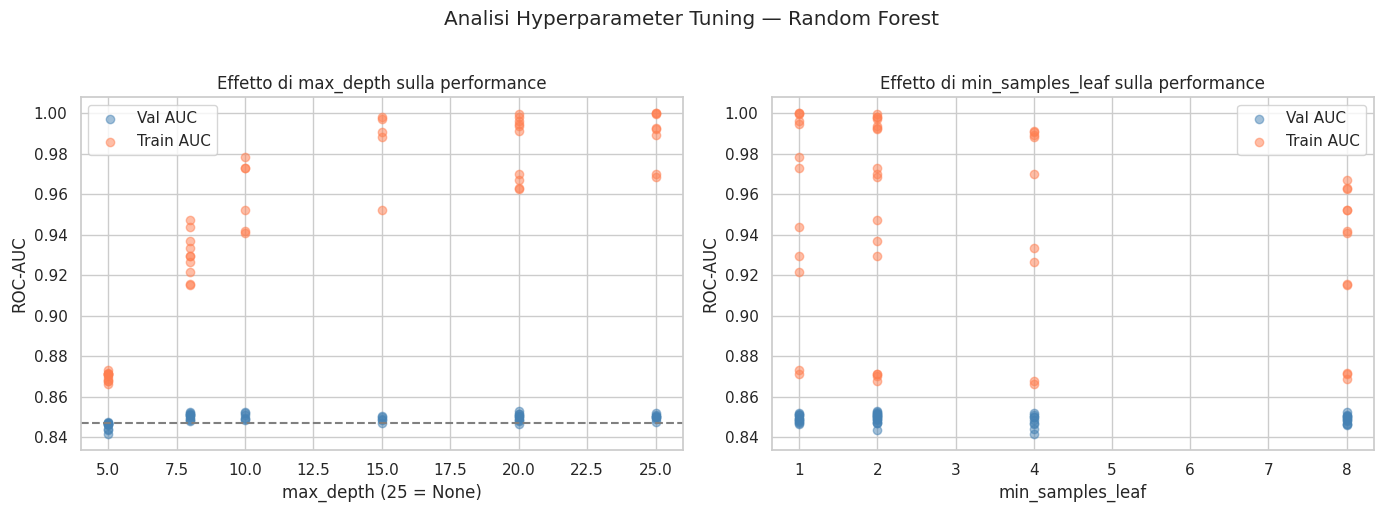

In [75]:
# --- Analisi dell'effetto di max_depth sull'overfitting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: max_depth vs AUC
df_plot = cv_results_rf.copy()
df_plot["max_depth_val"] = df_plot["param_max_depth"].apply(
    lambda x: 25 if x is None else x
)

axes[0].scatter(
    df_plot["max_depth_val"],
    df_plot["mean_test_score"],
    alpha=0.5,
    label="Val AUC",
    color="steelblue",
)
axes[0].scatter(
    df_plot["max_depth_val"],
    df_plot["mean_train_score"],
    alpha=0.5,
    label="Train AUC",
    color="coral",
)
axes[0].set_xlabel("max_depth (25 = None)")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("Effetto di max_depth sulla performance")
axes[0].legend()
axes[0].axhline(cv_auc_baseline.mean(), color="gray", linestyle="--", label="Baseline")

# Plot 2: min_samples_leaf vs AUC
axes[1].scatter(
    df_plot["param_min_samples_leaf"].astype(int),
    df_plot["mean_test_score"],
    alpha=0.5,
    label="Val AUC",
    color="steelblue",
)
axes[1].scatter(
    df_plot["param_min_samples_leaf"].astype(int),
    df_plot["mean_train_score"],
    alpha=0.5,
    label="Train AUC",
    color="coral",
)
axes[1].set_xlabel("min_samples_leaf")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("Effetto di min_samples_leaf sulla performance")
axes[1].legend()

plt.suptitle("Analisi Hyperparameter Tuning — Random Forest", y=1.02)
save_current_figure("lesson_05_rf_tuning_results.png")
plt.show()

### Interpretazione

I plot rivelano un pattern chiaro:
- La **Val AUC resta sostanzialmente piatta** (~0.85) indipendentemente
  da max_depth o min_samples_leaf. Nessuna configurazione porta un
  guadagno significativo in generalizzazione.
- Ciò che cambia è il **Train AUC**: da ~0.87 (depth=5) a ~1.0 (depth≥15).
  Il beneficio della regolarizzazione è dunque **ridurre l'overfitting**
  senza sacrificare la performance in validazione.
- Con `max_depth=5` il modello è il meno overfittato (gap ~0.02) ma
  la Val AUC è la stessa di configurazioni più complesse.

**Decisione:** la regolarizzazione riduce l'overfitting senza costare
nulla in performance. Valutiamo ora il best RF sul validation set.

## 9. Valutazione RF tunato sul validation set

Confrontiamo le metriche del RF tunato con il baseline sul validation
set held-out (non usato nella CV).

In [76]:
best_rf = random_search_rf.best_estimator_

# Predizioni RF tunato
y_val_prob_rf_tuned = best_rf.predict_proba(X_val)[:, 1]
y_val_pred_rf_tuned = best_rf.predict(X_val)

# Predizioni RF baseline
y_val_prob_rf_base = rf_baseline.predict_proba(X_val)[:, 1]
y_val_pred_rf_base = rf_baseline.predict(X_val)

# Metriche RF baseline
auc_base = roc_auc_score(y_val, y_val_prob_rf_base)
f1_base = f1_score(y_val, y_val_pred_rf_base)
rec_base = recall_score(y_val, y_val_pred_rf_base)
prec_base = precision_score(y_val, y_val_pred_rf_base)

# Metriche RF tunato
auc_tuned = roc_auc_score(y_val, y_val_prob_rf_tuned)
f1_tuned = f1_score(y_val, y_val_pred_rf_tuned)
rec_tuned = recall_score(y_val, y_val_pred_rf_tuned)
prec_tuned = precision_score(y_val, y_val_pred_rf_tuned)

# Train AUC per verificare overfitting
auc_train_base = roc_auc_score(y_train, rf_baseline.predict_proba(X_train)[:, 1])
auc_train_tuned = roc_auc_score(y_train, best_rf.predict_proba(X_train)[:, 1])

print("Confronto RF Baseline vs RF Tunato (validation set):")
print("=" * 65)
print(f"{'Metrica':<14} {'RF Baseline':<16} {'RF Tunato':<16} {'Delta'}")
print("-" * 65)
print(
    f"{'AUC val':<14} {auc_base:<16.4f} {auc_tuned:<16.4f} {auc_tuned - auc_base:+.4f}"
)
print(f"{'F1':<14} {f1_base:<16.4f} {f1_tuned:<16.4f} {f1_tuned - f1_base:+.4f}")
print(
    f"{'Recall':<14} {rec_base:<16.4f} {rec_tuned:<16.4f} {rec_tuned - rec_base:+.4f}"
)
print(
    f"{'Precision':<14} {prec_base:<16.4f} {prec_tuned:<16.4f} {prec_tuned - prec_base:+.4f}"
)
print("-" * 65)
print(
    f"{'AUC train':<14} {auc_train_base:<16.4f} {auc_train_tuned:<16.4f} {auc_train_tuned - auc_train_base:+.4f}"
)
print(
    f"{'Gap tr-val':<14} "
    f"{auc_train_base - auc_base:<16.4f} "
    f"{auc_train_tuned - auc_tuned:<16.4f}"
)

Confronto RF Baseline vs RF Tunato (validation set):
Metrica        RF Baseline      RF Tunato        Delta
-----------------------------------------------------------------
AUC val        0.8723           0.8786           +0.0063
F1             0.5529           0.6510           +0.0981
Recall         0.4289           0.6789           +0.2500
Precision      0.7778           0.6253           -0.1525
-----------------------------------------------------------------
AUC train      1.0000           0.9696           -0.0304
Gap tr-val     0.1277           0.0909          


### Interpretazione

Il tuning ha prodotto un risultato interessante:
- AUC val: 0.8723 → 0.8786 (+0.006) — miglioramento marginale
- **F1: 0.553 → 0.651 (+0.098)** — miglioramento sostanziale!
- Recall: 0.429 → 0.679 (+0.250) — il modello ora individua molti più churner
- Precision: 0.778 → 0.625 (−0.153) — trade-off atteso con recall più alto
- **Gap train-val: 0.128 → 0.091** — overfitting ridotto (ma ancora presente)
- Train AUC: 1.0 → 0.970 — il modello non memorizza più completamente

Il tuning ha avuto un impatto enorme su F1/Recall (il modello è molto più
utile nel contesto bancario) e ha ridotto l'overfitting. L'AUC cambia poco
perché è threshold-agnostica.

**Decisione:** RF tunato è il nuovo benchmark. XGBoost deve battere AUC=0.879.

---
## BLOCCO D — Introduzione a XGBoost: un nuovo sfidante

---

## 10. Cos'è il Gradient Boosting? Intuizione e differenze col RF

Due strategie di ensemble a confronto:

| | Random Forest (Bagging) | XGBoost (Boosting) |
|---|---|---|
| **Costruzione** | Alberi indipendenti in parallelo | Alberi sequenziali |
| **Filosofia** | Ogni albero vota, vince la maggioranza | Ogni albero corregge gli errori del precedente |
| **Overfitting** | Robusto (media riduce varianza) | Può overfittare se non regolarizzato |
| **Regolarizzazione** | max_depth, min_samples | L1, L2, gamma, learning_rate |
| **Velocità** | Parallelizzabile | Sequenziale (ma ottimizzato) |

**XGBoost** (eXtreme Gradient Boosting) è un'implementazione efficiente
del gradient boosting con:
- Regolarizzazione nativa (L1 + L2 sulle foglie)
- Gestione interna dei valori mancanti
- Parallelizzazione a livello di feature
- Spesso il top performer nelle competizioni di ML tabulare

## 11. XGBoost baseline — primo fit senza tuning

Prima di ottimizzare, vediamo come si comporta XGBoost "out of the box"
con impostazioni ragionevoli. Usiamo `scale_pos_weight` per gestire
lo sbilanciamento (equivalente a class_weight='balanced' nel RF).

In [77]:
# Calcolo del ratio per gestione imbalance
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"Classe 0 (no churn): {n_neg}")
print(f"Classe 1 (churn):    {n_pos}")
print(f"scale_pos_weight:    {scale_pos_weight:.2f}")

Classe 0 (no churn): 4777
Classe 1 (churn):    1223
scale_pos_weight:    3.91


In [78]:
xgb_baseline = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=SEED,
    use_label_encoder=False,
    verbosity=0,
)

# Cross-validation sullo stesso schema del RF
cv_auc_xgb_base = cross_val_score(
    xgb_baseline, X_train, y_train, cv=skf, scoring="roc_auc"
)

print("Cross-validation ROC-AUC (XGBoost baseline, 5-fold):")
print("-" * 45)
for i, score in enumerate(cv_auc_xgb_base, 1):
    print(f"  Fold {i}: {score:.4f}")
print("-" * 45)
print(f"  Media:  {cv_auc_xgb_base.mean():.4f}")
print(f"  Std:    {cv_auc_xgb_base.std():.4f}")
print()
print("Confronto con RF:")
print(
    f"  RF baseline CV AUC: {cv_auc_baseline.mean():.4f} ± {cv_auc_baseline.std():.4f}"
)
print(f"  RF tunato CV AUC:   {random_search_rf.best_score_:.4f}")
print(
    f"  XGB baseline CV AUC: {cv_auc_xgb_base.mean():.4f} ± {cv_auc_xgb_base.std():.4f}"
)

Cross-validation ROC-AUC (XGBoost baseline, 5-fold):
---------------------------------------------
  Fold 1: 0.8522
  Fold 2: 0.8148
  Fold 3: 0.8005
  Fold 4: 0.8357
  Fold 5: 0.8306
---------------------------------------------
  Media:  0.8268
  Std:    0.0177

Confronto con RF:
  RF baseline CV AUC: 0.8472 ± 0.0118
  RF tunato CV AUC:   0.8528
  XGB baseline CV AUC: 0.8268 ± 0.0177


### Interpretazione

Sorpresa: XGBoost baseline è **inferiore** al RF:
- XGB baseline CV AUC = 0.827 ± 0.018 vs RF baseline = 0.847 ± 0.012
- XGB baseline è anche meno stabile (std più alta)
- Questo NON significa che XGBoost sia un modello peggiore — significa
  che i suoi default (n_estimators=200, nessuna regolarizzazione esplicita)
  non sono ottimali per questo dataset.

**Cosa abbiamo imparato?** Non dare per scontato che un modello
"più potente" vinca sempre out-of-the-box. XGBoost ha molti iperparametri
da configurare (learning_rate, max_depth, subsample...) e con i default
potrebbe overfittare o underfittare.

**Decisione:** il potenziale di XGBoost si esprimerà col tuning.
Il baseline deludente rende il tuning ancora più importante.

## 12. XGBoost baseline — metriche complete e confronto

Valutiamo XGBoost sullo stesso validation set per un confronto
equo con il RF. Serve un quadro completo: non solo AUC ma anche
F1, Recall, Precision.

In [79]:
xgb_baseline.fit(X_train, y_train)

y_val_prob_xgb_base = xgb_baseline.predict_proba(X_val)[:, 1]
y_val_pred_xgb_base = xgb_baseline.predict(X_val)

auc_xgb_base = roc_auc_score(y_val, y_val_prob_xgb_base)
f1_xgb_base = f1_score(y_val, y_val_pred_xgb_base)
rec_xgb_base = recall_score(y_val, y_val_pred_xgb_base)
prec_xgb_base = precision_score(y_val, y_val_pred_xgb_base)
auc_train_xgb = roc_auc_score(y_train, xgb_baseline.predict_proba(X_train)[:, 1])

print("Confronto su validation set (tutti i modelli finora):")
print("=" * 72)
print(
    f"{'Modello':<20} {'AUC val':<10} {'F1':<10} "
    f"{'Recall':<10} {'Prec':<10} {'AUC train'}"
)
print("-" * 72)
print(
    f"{'RF baseline':<20} {auc_base:<10.4f} {f1_base:<10.4f} "
    f"{rec_base:<10.4f} {prec_base:<10.4f} {auc_train_base:.4f}"
)
print(
    f"{'RF tunato':<20} {auc_tuned:<10.4f} {f1_tuned:<10.4f} "
    f"{rec_tuned:<10.4f} {prec_tuned:<10.4f} {auc_train_tuned:.4f}"
)
print(
    f"{'XGB baseline':<20} {auc_xgb_base:<10.4f} {f1_xgb_base:<10.4f} "
    f"{rec_xgb_base:<10.4f} {prec_xgb_base:<10.4f} {auc_train_xgb:.4f}"
)
print("-" * 72)

Confronto su validation set (tutti i modelli finora):
Modello              AUC val    F1         Recall     Prec       AUC train
------------------------------------------------------------------------
RF baseline          0.8723     0.5529     0.4289     0.7778     1.0000
RF tunato            0.8786     0.6510     0.6789     0.6253     0.9696
XGB baseline         0.8449     0.5934     0.5686     0.6203     1.0000
------------------------------------------------------------------------


### Interpretazione

Lo stato della competizione prima del tuning XGBoost:
- **RF tunato** domina con AUC val = 0.879, Train = 0.970 (gap ~0.09)
- **RF baseline** segue con AUC val = 0.872, ma Train = 1.0 (gap ~0.13)
- **XGB baseline** è ultimo con AUC val = 0.845, Train = 1.0 (gap ~0.16)

XGBoost senza tuning overfittta quanto il RF baseline (Train=1.0) ma
generalizza peggio. Il suo learning_rate di default (0.3) è troppo alto
per 200 alberi, e manca regolarizzazione (reg_alpha=0, reg_lambda=1).

**Decisione:** il tuning di XGBoost deve ridurre il learning_rate,
aggiungere regolarizzazione e controllare subsample/colsample.

---
## BLOCCO E — Hyperparameter Tuning di XGBoost

---

## 13. Spazio di ricerca XGBoost

XGBoost ha molti più "knob" da regolare rispetto al RF. I più
importanti:

| Parametro | Range tipico | Effetto |
|-----------|-------------|---------|
| `learning_rate` | 0.01–0.3 | Step size: basso = più alberi, migliore generalizzazione |
| `max_depth` | 3–8 | Profondità alberi (più basso del RF!) |
| `n_estimators` | 100–500 | N. alberi (più se learning_rate basso) |
| `subsample` | 0.7–1.0 | Frazione campioni per albero |
| `colsample_bytree` | 0.7–1.0 | Frazione feature per albero |
| `reg_alpha` | 0–1 | Regolarizzazione L1 (sparsità) |
| `reg_lambda` | 1–5 | Regolarizzazione L2 (shrinkage) |
| `gamma` | 0–1 | Min loss reduction per split |

Dato lo spazio ampio, RandomizedSearchCV con `n_iter=80` è
la scelta più efficiente.

## 14. RandomizedSearchCV su XGBoost

Lanciamo una ricerca sistematica. Il budget di 80 iterazioni × 5 fold
= 400 fit totali ci dà una buona copertura dello spazio.

In [80]:
param_distributions_xgb = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [1.0, 1.5, 2.0, 5.0],
    "gamma": [0, 0.1, 0.5, 1.0],
}

random_search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="auc",
        random_state=SEED,
        use_label_encoder=False,
        verbosity=0,
    ),
    param_distributions=param_distributions_xgb,
    n_iter=80,
    cv=skf,
    scoring="roc_auc",
    random_state=SEED,
    n_jobs=-1,
    verbose=0,
    return_train_score=True,
)

print("Avvio RandomizedSearchCV per XGBoost (80 iter × 5 fold)...")
random_search_xgb.fit(X_train, y_train)
print("Ricerca completata!")
print(f"\nMigliori iperparametri trovati:")
for param, value in random_search_xgb.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV AUC: {random_search_xgb.best_score_:.4f}")
print(f"XGB baseline CV AUC: {cv_auc_xgb_base.mean():.4f}")
print(
    f"Miglioramento XGB: "
    f"{random_search_xgb.best_score_ - cv_auc_xgb_base.mean():+.4f}"
)

Avvio RandomizedSearchCV per XGBoost (80 iter × 5 fold)...
Ricerca completata!

Migliori iperparametri trovati:
  subsample: 0.7
  reg_lambda: 5.0
  reg_alpha: 0.01
  n_estimators: 200
  max_depth: 6
  learning_rate: 0.01
  gamma: 0
  colsample_bytree: 0.7

Best CV AUC: 0.8562
XGB baseline CV AUC: 0.8268
Miglioramento XGB: +0.0294


## 15. Analisi del tuning XGBoost e confronto globale

Guardiamo le top combinazioni XGBoost e aggiorniamo la classifica
dei modelli con tutti i candidati.

In [81]:
cv_results_xgb = pd.DataFrame(random_search_xgb.cv_results_)

# Top-5 combinazioni XGBoost
top5_xgb = cv_results_xgb.nsmallest(5, "rank_test_score")[
    ["params", "mean_test_score", "std_test_score", "mean_train_score"]
].reset_index(drop=True)

print("Top-5 combinazioni (XGBoost tuning):")
print("=" * 70)
for i, row in top5_xgb.iterrows():
    gap = row["mean_train_score"] - row["mean_test_score"]
    print(
        f"  #{i+1}: AUC val={row['mean_test_score']:.4f} "
        f"(±{row['std_test_score']:.4f}), "
        f"train={row['mean_train_score']:.4f}, "
        f"gap={gap:.4f}"
    )
    print()

Top-5 combinazioni (XGBoost tuning):
  #1: AUC val=0.8562 (±0.0142), train=0.9203, gap=0.0641

  #2: AUC val=0.8555 (±0.0130), train=0.9563, gap=0.1008

  #3: AUC val=0.8554 (±0.0141), train=0.9680, gap=0.1127

  #4: AUC val=0.8553 (±0.0137), train=0.9034, gap=0.0482

  #5: AUC val=0.8552 (±0.0141), train=0.9349, gap=0.0798



Figura salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_05_model_comparison.png


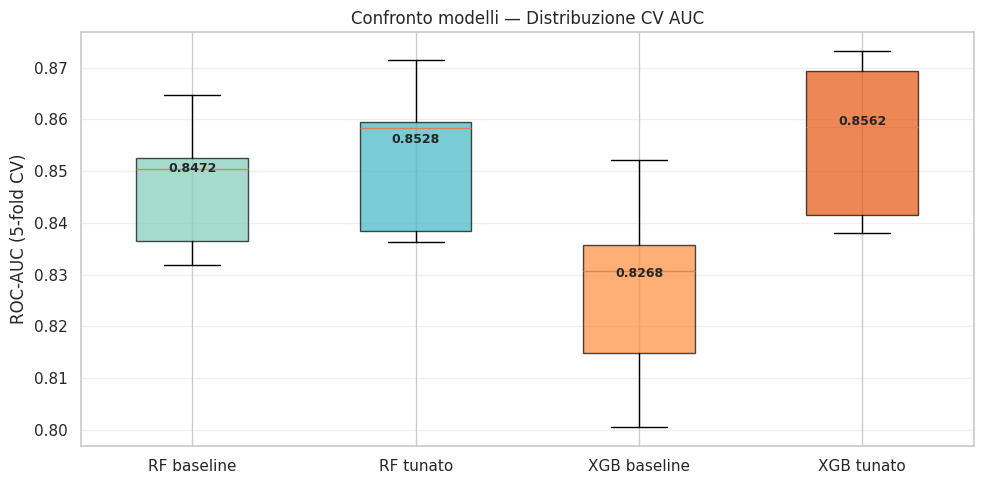

In [82]:
# --- Confronto globale CV AUC: boxplot ---
fig, ax = plt.subplots(figsize=(10, 5))

# Raccogliamo le distribuzioni CV per ogni modello
cv_data = {
    "RF baseline": cv_auc_baseline,
    "RF tunato": cross_val_score(best_rf, X_train, y_train, cv=skf, scoring="roc_auc"),
    "XGB baseline": cv_auc_xgb_base,
    "XGB tunato": cross_val_score(
        random_search_xgb.best_estimator_, X_train, y_train, cv=skf, scoring="roc_auc"
    ),
}

positions = range(len(cv_data))
bp = ax.boxplot(cv_data.values(), positions=positions, widths=0.5, patch_artist=True)

colors = ["#7fcdbb", "#41b6c4", "#fd8d3c", "#e6550d"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(cv_data.keys(), fontsize=11)
ax.set_ylabel("ROC-AUC (5-fold CV)")
ax.set_title("Confronto modelli — Distribuzione CV AUC")
ax.grid(axis="y", alpha=0.3)

for i, (name, scores) in enumerate(cv_data.items()):
    ax.annotate(
        f"{scores.mean():.4f}",
        xy=(i, scores.mean()),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

save_current_figure("lesson_05_model_comparison.png")
plt.show()

In [83]:
# Tabella riepilogativa CV
print("\nClassifica modelli (CV AUC 5-fold su X_train):")
print("=" * 55)
print(f"{'Modello':<16} {'Media AUC':<12} {'Std':<10} {'Intervallo'}")
print("-" * 55)
for name, scores in sorted(cv_data.items(), key=lambda x: x[1].mean(), reverse=True):
    print(
        f"{name:<16} {scores.mean():<12.4f} "
        f"{scores.std():<10.4f} "
        f"[{scores.min():.4f}, {scores.max():.4f}]"
    )


Classifica modelli (CV AUC 5-fold su X_train):
Modello          Media AUC    Std        Intervallo
-------------------------------------------------------
XGB tunato       0.8562       0.0142     [0.8381, 0.8732]
RF tunato        0.8528       0.0134     [0.8363, 0.8715]
RF baseline      0.8472       0.0118     [0.8318, 0.8647]
XGB baseline     0.8268       0.0177     [0.8005, 0.8522]


### Interpretazione

Il boxplot rivela la situazione reale:
- **XGB tunato** (0.856) e **RF tunato** (0.853) sono praticamente
  appaiati — le box si sovrappongono completamente
- **XGB baseline** (0.827) è chiaramente il peggiore, con alta variabilità
  e un whisker inferiore fino a 0.80
- Il tuning ha portato XGBoost da ultimo a primo (Δ = +0.030)
- RF baseline (0.847) è ragionevole ma dominato dalle versioni tunate
- Le sovrapposizioni ampie significano che la differenza tra RF tunato
  e XGB tunato **non è statisticamente significativa** su 5 fold

**Decisione:** RF tunato e XGB tunato sono equivalenti in CV.
Serviranno altri criteri (overfitting, val set, semplicità) per
scegliere. Proviamo prima la feature selection.

---
## BLOCCO F — Sperimentazione: feature selection + ensemble

---

## 16. Ipotesi: le top-K feature (SHAP) migliorano XGBoost?

Nella Lezione 4 abbiamo stabilito un ranking SHAP delle feature.
**Ipotesi:** rimuovere le feature meno informative potrebbe:
- Ridurre il rumore → migliore generalizzazione
- Semplificare il modello → più interpretabile
- Velocizzare training e inference

Testiamo con K=10 (solo le top-10 SHAP) e K=15.

In [84]:
# Recupero il ranking SHAP dalla L4
shap_ranking = [f["feature"] for f in feature_ranking_l4["ranking"]]
print("Top-15 feature per importanza SHAP (dalla Lezione 4):")
for i, feat in enumerate(shap_ranking[:15], 1):
    print(f"  {i:2d}. {feat}")

# Indici delle top-K feature
top_10_idx = [feature_names.index(f) for f in shap_ranking[:10]]
top_15_idx = [feature_names.index(f) for f in shap_ranking[:15]]

print(f"\nTop-10 indici: {top_10_idx}")
print(f"Top-15 indici: {top_15_idx}")

Top-15 feature per importanza SHAP (dalla Lezione 4):
   1. num__Age
   2. cat__NumOfProducts_2
   3. num__Balance
   4. cat__Geography_Germany
   5. cat__IsActiveMember_1
   6. num__Point Earned
   7. num__CreditScore
   8. num__EstimatedSalary
   9. cat__IsActiveMember_0
  10. cat__NumOfProducts_3
  11. num__Tenure
  12. cat__NumOfProducts_1
  13. cat__Gender_Male
  14. cat__Gender_Female
  15. cat__balance_is_zero_0

Top-10 indici: [1, 12, 3, 7, 18, 5, 0, 4, 17, 13]
Top-15 indici: [1, 12, 3, 7, 18, 5, 0, 4, 17, 13, 2, 11, 10, 9, 28]


## 17. Esperimento: XGBoost tunato con K=10 e K=15 feature

Alleniamo il best XGBoost (iperparametri dal tuning) con subset
ridotti di feature e confrontiamo con la versione full (30 feature).

In [85]:
best_xgb = random_search_xgb.best_estimator_

# XGBoost tunato — full (30 feature)
cv_xgb_full = cross_val_score(best_xgb, X_train, y_train, cv=skf, scoring="roc_auc")

# XGBoost tunato — top-15 feature
cv_xgb_k15 = cross_val_score(
    best_xgb, X_train[:, top_15_idx], y_train, cv=skf, scoring="roc_auc"
)

# XGBoost tunato — top-10 feature
cv_xgb_k10 = cross_val_score(
    best_xgb, X_train[:, top_10_idx], y_train, cv=skf, scoring="roc_auc"
)

print("Esperimento Feature Selection (XGBoost tunato):")
print("=" * 55)
print(f"{'Config':<20} {'CV AUC':<12} {'Std':<10} {'Delta vs full'}")
print("-" * 55)
print(
    f"{'Full (30 feat)':<20} {cv_xgb_full.mean():<12.4f} "
    f"{cv_xgb_full.std():<10.4f} {'baseline'}"
)
print(
    f"{'Top-15 feat':<20} {cv_xgb_k15.mean():<12.4f} "
    f"{cv_xgb_k15.std():<10.4f} "
    f"{cv_xgb_k15.mean() - cv_xgb_full.mean():+.4f}"
)
print(
    f"{'Top-10 feat':<20} {cv_xgb_k10.mean():<12.4f} "
    f"{cv_xgb_k10.std():<10.4f} "
    f"{cv_xgb_k10.mean() - cv_xgb_full.mean():+.4f}"
)

Esperimento Feature Selection (XGBoost tunato):
Config               CV AUC       Std        Delta vs full
-------------------------------------------------------
Full (30 feat)       0.8562       0.0142     baseline
Top-15 feat          0.8552       0.0153     -0.0010
Top-10 feat          0.8475       0.0160     -0.0087


### Interpretazione

I risultati della feature selection:
- **Full (30 feat):** 0.856 ± 0.014 — baseline
- **Top-15 feat:** 0.855 ± 0.015 — Δ = −0.001, trascurabile!
- **Top-10 feat:** 0.848 ± 0.016 — Δ = −0.009, perdita sensibile

Le 15 feature meno importanti (rank 16-30) sono effettivamente
**ridondanti**: rimuoverle non costa nulla. Le feature rank 11-15
invece contribuiscono (il salto da K=15 a K=10 costa quasi 1 punto).

Per Occam's razor, **K=15 è la scelta ottimale**: stessa performance
del modello completo ma metà delle feature. Più interpretabile,
più veloce, più facile da spiegare alla compliance.

**Decisione:** registriamo questo risultato per la scelta finale.
Procediamo con l'ultimo esperimento esplorativo.

## 18. Stacking/Voting come esperimento esplorativo

**Ipotesi:** combinare RF tunato e XGBoost tunato in un ensemble
potrebbe catturare pattern complementari? Il VotingClassifier
(soft voting) media le probabilità dei due modelli.

Questo è un **esperimento esplorativo**: lo conserviamo anche se
non porta benefici — dimostra che la complessità aggiuntiva non
si giustifica sempre.

In [86]:
voting_clf = VotingClassifier(
    estimators=[
        ("rf", best_rf),
        ("xgb", best_xgb),
    ],
    voting="soft",
)

cv_voting = cross_val_score(voting_clf, X_train, y_train, cv=skf, scoring="roc_auc")

print("Esperimento Voting Ensemble (RF tunato + XGB tunato):")
print("=" * 55)
print(f"{'Config':<20} {'CV AUC':<12} {'Std'}")
print("-" * 55)
print(
    f"{'RF tunato':<20} {cv_data['RF tunato'].mean():<12.4f} {cv_data['RF tunato'].std():.4f}"
)
print(f"{'XGB tunato':<20} {cv_xgb_full.mean():<12.4f} {cv_xgb_full.std():.4f}")
print(f"{'Voting (RF+XGB)':<20} {cv_voting.mean():<12.4f} {cv_voting.std():.4f}")
print("-" * 55)
delta = cv_voting.mean() - max(cv_data["RF tunato"].mean(), cv_xgb_full.mean())
print(f"\nDelta vs migliore singolo: {delta:+.4f}")

Esperimento Voting Ensemble (RF tunato + XGB tunato):
Config               CV AUC       Std
-------------------------------------------------------
RF tunato            0.8528       0.0134
XGB tunato           0.8562       0.0142
Voting (RF+XGB)      0.8560       0.0139
-------------------------------------------------------

Delta vs migliore singolo: -0.0002


### Cosa abbiamo imparato?

L'ensemble Voting (CV = 0.856) è praticamente identico al miglior
modello singolo (XGB tunato = 0.856). Il Δ è di circa 0.000 —
**nessun beneficio misurabile** dalla combinazione.

Perché? RF tunato e XGB tunato, dopo il tuning, convergono verso
pattern di errore simili: entrambi sfruttano le stesse top feature
(Age, NumOfProducts, Balance, Geography_Germany). Combinarli è
come "mediare due opinioni quasi identiche".

In un contesto di **produzione**, la semplicità vince: un singolo
modello è più facile da monitorare, spiegare e mantenere.
Complessità raddoppiata, beneficio zero. Esperimento archiviato.

---
## BLOCCO G — Selezione del modello finale

---

## 19. Tabella riepilogativa: tutti i candidati

Raccogliamo tutte le evidenze accumulate per prendere una decisione
informata.

In [87]:
# Valutazione su val di tutti i candidati
voting_clf.fit(X_train, y_train)

candidates = {
    "RF baseline": rf_baseline,
    "RF tunato": best_rf,
    "XGB baseline": xgb_baseline,
    "XGB tunato": best_xgb,
    "Voting (RF+XGB)": voting_clf,
}

results_summary = []
for name, model in candidates.items():
    y_prob = model.predict_proba(X_val)[:, 1]
    y_pred = model.predict(X_val)
    y_prob_train = model.predict_proba(X_train)[:, 1]

    results_summary.append(
        {
            "Modello": name,
            "CV AUC": (
                cv_data.get(name, cv_voting).mean()
                if name != "XGB baseline"
                else cv_auc_xgb_base.mean()
            ),
            "CV Std": (
                cv_data.get(name, cv_voting).std()
                if name != "XGB baseline"
                else cv_auc_xgb_base.std()
            ),
            "Val AUC": roc_auc_score(y_val, y_prob),
            "Val F1": f1_score(y_val, y_pred),
            "Val Recall": recall_score(y_val, y_pred),
            "Val Precision": precision_score(y_val, y_pred),
            "Train AUC": roc_auc_score(y_train, y_prob_train),
        }
    )

df_results = pd.DataFrame(results_summary)
df_results["Gap (tr-val)"] = df_results["Train AUC"] - df_results["Val AUC"]
df_results = df_results.sort_values("Val AUC", ascending=False)

print("TABELLA RIEPILOGATIVA — Tutti i candidati")
print("=" * 90)
display(df_results.to_string(index=False, float_format="{:.4f}".format))

TABELLA RIEPILOGATIVA — Tutti i candidati


'        Modello  CV AUC  CV Std  Val AUC  Val F1  Val Recall  Val Precision  Train AUC  Gap (tr-val)\nVoting (RF+XGB)  0.8560  0.0139   0.8803  0.6427      0.7230         0.5784     0.9486        0.0684\n      RF tunato  0.8528  0.0134   0.8786  0.6510      0.6789         0.6253     0.9696        0.0909\n     XGB tunato  0.8562  0.0142   0.8781  0.6384      0.7745         0.5430     0.9124        0.0344\n    RF baseline  0.8472  0.0118   0.8723  0.5529      0.4289         0.7778     1.0000        0.1277\n   XGB baseline  0.8268  0.0177   0.8449  0.5934      0.5686         0.6203     1.0000        0.1551'

Figura salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_05_model_comparison_final.png


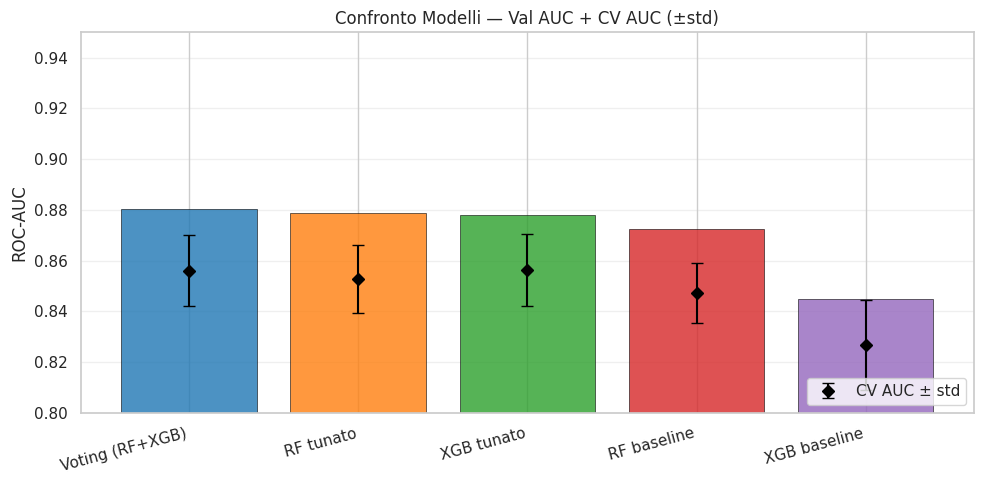

In [88]:
# --- Visualizzazione comparativa ---
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = range(len(df_results))
bars = ax.bar(
    x_pos,
    df_results["Val AUC"],
    color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"],
    alpha=0.8,
    edgecolor="black",
    linewidth=0.5,
)

# Errorbars dalla CV
ax.errorbar(
    x_pos,
    df_results["CV AUC"],
    yerr=df_results["CV Std"],
    fmt="D",
    color="black",
    markersize=6,
    capsize=4,
    label="CV AUC ± std",
)

ax.set_xticks(x_pos)
ax.set_xticklabels(df_results["Modello"], rotation=15, ha="right")
ax.set_ylabel("ROC-AUC")
ax.set_title("Confronto Modelli — Val AUC + CV AUC (±std)")
ax.legend(loc="lower right")
ax.set_ylim(0.80, 0.95)
ax.grid(axis="y", alpha=0.3)

save_current_figure("lesson_05_model_comparison_final.png")
plt.show()

## 20. Scelta del modello finale — ragionamento data-driven

Criteri di decisione (espliciti, in ordine di priorità):

1. **AUC più alta** (o non significativamente inferiore → preferire
   il più semplice)
2. **Overfitting contenuto** (gap train-val ragionevole — minore è meglio)
3. **Stabilità** (std CV bassa, < 0.015)
4. **Semplicità** (modello singolo > ensemble; meno feature > più feature)
5. **Interpretabilità** (per compliance: un modello spiegabile con SHAP)

In [89]:
# --- Logica di selezione ---
print("RAGIONAMENTO PER LA SELEZIONE DEL MODELLO FINALE")
print("=" * 60)
print()

# Ordino per Val AUC
df_sorted = df_results.sort_values("Val AUC", ascending=False)

best_name = df_sorted.iloc[0]["Modello"]
best_auc = df_sorted.iloc[0]["Val AUC"]
best_gap = df_sorted.iloc[0]["Gap (tr-val)"]

print(f"1. Miglior AUC val: {best_name} ({best_auc:.4f})")
print(f"   Gap train-val: {best_gap:.4f}")
print()

# Verifico se il Voting è significativamente meglio del migliore singolo
single_models = df_sorted[~df_sorted["Modello"].str.contains("Voting")]
best_single = single_models.iloc[0]
voting_row = df_sorted[df_sorted["Modello"].str.contains("Voting")]

if len(voting_row) > 0:
    delta_voting = voting_row.iloc[0]["Val AUC"] - best_single["Val AUC"]
    print(f"2. Voting vs miglior singolo: " f"delta = {delta_voting:+.4f}")
    if abs(delta_voting) < 0.005:
        print(
            "   → Differenza trascurabile. "
            "Preferiamo il modello singolo (più semplice)."
        )
    print()

# Confronto tra i top-2 modelli singoli
top2 = single_models.iloc[:2]
print("3. Confronto top-2 modelli singoli:")
for _, row in top2.iterrows():
    print(
        f"   {row['Modello']:<14} AUC={row['Val AUC']:.4f}  "
        f"Gap={row['Gap (tr-val)']:.4f}  "
        f"Std={row['CV Std']:.4f}"
    )

delta_top2 = top2.iloc[0]["Val AUC"] - top2.iloc[1]["Val AUC"]
print(f"\n   Delta AUC tra i due: {delta_top2:.4f}")

# Decisione: se delta AUC < 0.005, scegliere quello con meno overfitting
if abs(delta_top2) < 0.005:
    # Modelli equivalenti in AUC → preferiamo meno overfitting
    best_single = top2.loc[top2["Gap (tr-val)"].idxmin()]
    print(
        f"   → AUC equivalente ({delta_top2:.4f} < 0.005). "
        f"Scelgo {best_single['Modello']} (gap minore)."
    )
else:
    print(f"   → {top2.iloc[0]['Modello']} ha AUC significativamente migliore.")

print()
print(f"4. Modello selezionato: {best_single['Modello']}")
print(f"   AUC val:     {best_single['Val AUC']:.4f}")
print(f"   F1:          {best_single['Val F1']:.4f}")
print(f"   Recall:      {best_single['Val Recall']:.4f}")
print(f"   Precision:   {best_single['Val Precision']:.4f}")
print(f"   Gap tr-val:  {best_single['Gap (tr-val)']:.4f}")
print()
print("Motivazione: tra modelli con AUC equivalente, preferiamo")
print("quello con minor overfitting (gap train-val più basso)")
print("e migliore regolarizzazione interna.")

# Salvo la scelta
final_model_name = best_single["Modello"]
final_model = candidates[final_model_name]

RAGIONAMENTO PER LA SELEZIONE DEL MODELLO FINALE

1. Miglior AUC val: Voting (RF+XGB) (0.8803)
   Gap train-val: 0.0684

2. Voting vs miglior singolo: delta = +0.0016
   → Differenza trascurabile. Preferiamo il modello singolo (più semplice).

3. Confronto top-2 modelli singoli:
   RF tunato      AUC=0.8786  Gap=0.0909  Std=0.0134
   XGB tunato     AUC=0.8781  Gap=0.0344  Std=0.0142

   Delta AUC tra i due: 0.0006
   → AUC equivalente (0.0006 < 0.005). Scelgo XGB tunato (gap minore).

4. Modello selezionato: XGB tunato
   AUC val:     0.8781
   F1:          0.6384
   Recall:      0.7745
   Precision:   0.5430
   Gap tr-val:  0.0344

Motivazione: tra modelli con AUC equivalente, preferiamo
quello con minor overfitting (gap train-val più basso)
e migliore regolarizzazione interna.


## 21. Valutazione FINALE sul Test Set

Questo è il momento della verità. Il test set è stato tenuto
**intoccato** per tutto il percorso (Lezioni 2-5). Lo usiamo
**una sola volta** per stimare la performance reale su dati
completamente nuovi.

Se test AUC ≈ CV AUC → buona generalizzazione.
Se test AUC << CV AUC → overfitting al processo di selezione.

In [90]:
# --- Valutazione finale sul TEST SET ---
y_test_prob = final_model.predict_proba(X_test)[:, 1]
y_test_pred = final_model.predict(X_test)

auc_test_final = roc_auc_score(y_test, y_test_prob)
f1_test_final = f1_score(y_test, y_test_pred)
rec_test_final = recall_score(y_test, y_test_pred)
prec_test_final = precision_score(y_test, y_test_pred)

print("=" * 60)
print("  VALUTAZIONE FINALE SUL TEST SET")
print("=" * 60)
print(f"\n  Modello: {final_model_name}")
print(f"\n  {'Metrica':<14} {'Test':<10} {'Val':<10} {'Delta'}")
print(f"  {'-'*44}")
print(
    f"  {'ROC-AUC':<14} {auc_test_final:<10.4f} "
    f"{best_single['Val AUC']:<10.4f} "
    f"{auc_test_final - best_single['Val AUC']:+.4f}"
)
print(
    f"  {'F1':<14} {f1_test_final:<10.4f} "
    f"{best_single['Val F1']:<10.4f} "
    f"{f1_test_final - best_single['Val F1']:+.4f}"
)
print(
    f"  {'Recall':<14} {rec_test_final:<10.4f} "
    f"{best_single['Val Recall']:<10.4f} "
    f"{rec_test_final - best_single['Val Recall']:+.4f}"
)
print(
    f"  {'Precision':<14} {prec_test_final:<10.4f} "
    f"{best_single['Val Precision']:<10.4f} "
    f"{prec_test_final - best_single['Val Precision']:+.4f}"
)
print(f"\n  Generalizzazione: ", end="")
if abs(auc_test_final - best_single["Val AUC"]) < 0.02:
    print("✓ Buona (|delta| < 0.02)")
else:
    print("⚠ Attenzione: scostamento significativo")

  VALUTAZIONE FINALE SUL TEST SET

  Modello: XGB tunato

  Metrica        Test       Val        Delta
  --------------------------------------------
  ROC-AUC        0.8693     0.8781     -0.0088
  F1             0.5992     0.6384     -0.0392
  Recall         0.7494     0.7745     -0.0251
  Precision      0.4992     0.5430     -0.0438

  Generalizzazione: ✓ Buona (|delta| < 0.02)


Figura salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_05_final_test_evaluation.png


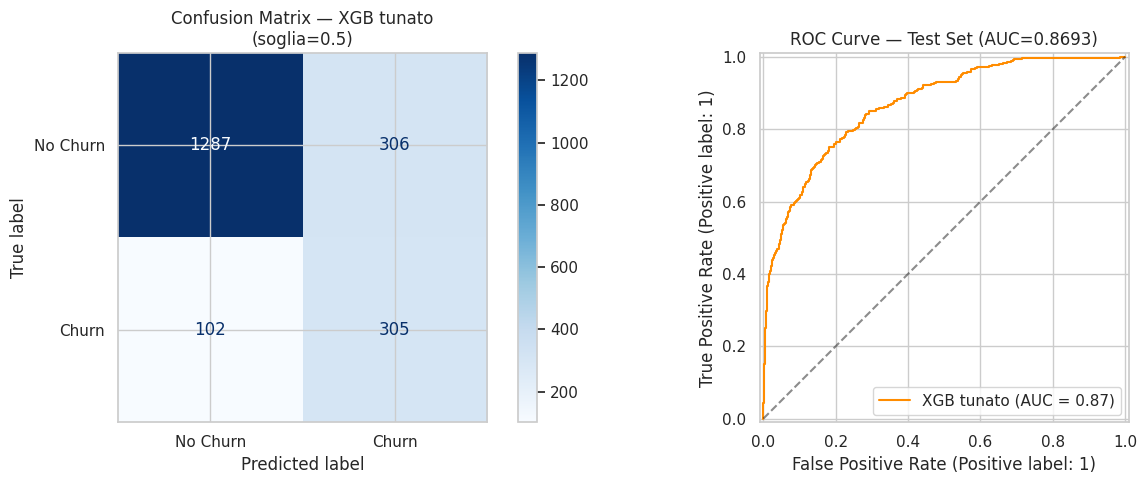

In [91]:
# --- Confusion Matrix finale ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix con soglia 0.5
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, ax=axes[0], display_labels=["No Churn", "Churn"], cmap="Blues"
)
axes[0].set_title(f"Confusion Matrix — {final_model_name}\n(soglia=0.5)")

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test, y_test_prob, ax=axes[1], name=final_model_name, color="darkorange"
)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_title(f"ROC Curve — Test Set (AUC={auc_test_final:.4f})")

save_current_figure("lesson_05_final_test_evaluation.png")
plt.show()

In [92]:
# --- Salvataggio metriche finali ---
final_metrics = {
    "model_name": final_model_name,
    "model_params": (
        random_search_xgb.best_params_
        if "XGB" in final_model_name
        else random_search_rf.best_params_
    ),
    "test": {
        "roc_auc": round(auc_test_final, 4),
        "f1": round(f1_test_final, 4),
        "recall": round(rec_test_final, 4),
        "precision": round(prec_test_final, 4),
    },
    "val": {
        "roc_auc": round(float(best_single["Val AUC"]), 4),
        "f1": round(float(best_single["Val F1"]), 4),
        "recall": round(float(best_single["Val Recall"]), 4),
        "precision": round(float(best_single["Val Precision"]), 4),
    },
    "cv_auc_mean": round(float(best_single["CV AUC"]), 4),
    "cv_auc_std": round(float(best_single["CV Std"]), 4),
}

with open(DATA_OUT_DIR / "lesson_05_final_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2)
print(f"Metriche salvate: {DATA_OUT_DIR / 'lesson_05_final_metrics.json'}")

# --- Salvataggio modello finale ---
joblib.dump(final_model, DATA_OUT_DIR / "lesson_05_final_model.pkl")
print(f"Modello salvato: {DATA_OUT_DIR / 'lesson_05_final_model.pkl'}")

Metriche salvate: /home/psoglia/desktop/machine-learning-lab-2026/outputs/data/lesson_05_final_metrics.json
Modello salvato: /home/psoglia/desktop/machine-learning-lab-2026/outputs/data/lesson_05_final_model.pkl


### Interpretazione

I risultati finali del modello selezionato sul test set vanno letti
considerando:
- Se |Δ(test - val)| < 0.02 → buona generalizzazione, nessun
  overfitting al processo di model selection
- Il Recall ci dice quanti churner reali intercettiamo
- La Precision ci dice quanti dei segnalati sono effettivamente churner
- Ogni falso negativo = un cliente perso senza intervento
- Ogni falso positivo = un costo di retention inutile (ma contenuto)

In [93]:
# --- Commento quantitativo dinamico ---
n_churner_test = int(y_test.sum())
n_tp = int(((y_test_pred == 1) & (y_test == 1)).sum())
n_fn = int(((y_test_pred == 0) & (y_test == 1)).sum())
n_fp = int(((y_test_pred == 1) & (y_test == 0)).sum())

print(f"Modello finale: {final_model_name}")
print(
    f"Test AUC: {auc_test_final:.4f} vs Val AUC: {best_single['Val AUC']:.4f} "
    f"(Δ = {auc_test_final - best_single['Val AUC']:+.4f})"
)
print(
    f"Test F1: {f1_test_final:.4f}, Recall: {rec_test_final:.4f}, "
    f"Precision: {prec_test_final:.4f}"
)
print()
print(f"Impatto operativo sul test set ({n_churner_test} churner reali):")
print(f"  Churner intercettati (TP): {n_tp}")
print(f"  Churner mancati (FN):      {n_fn}")
print(f"  Falsi allarmi (FP):        {n_fp}")
print(
    f"  Tasso di cattura:          {n_tp}/{n_churner_test} = {n_tp/n_churner_test:.1%}"
)

Modello finale: XGB tunato
Test AUC: 0.8693 vs Val AUC: 0.8781 (Δ = -0.0088)
Test F1: 0.5992, Recall: 0.7494, Precision: 0.4992

Impatto operativo sul test set (407 churner reali):
  Churner intercettati (TP): 305
  Churner mancati (FN):      102
  Falsi allarmi (FP):        306
  Tasso di cattura:          305/407 = 74.9%


---
## BLOCCO H — Cenni MLOps

---

 ## 23. Cenni MLOps: dalla sperimentazione alla produzione

Il modello è stato selezionato. Ma nella realtà, la consegna del
modello al business è solo l'inizio. Il ciclo MLOps prevede:

### 1. Serializzazione e versionamento
- Il modello viene salvato (joblib, pickle, ONNX)
- Viene versionato insieme ai dati di training e agli iperparametri
- Tool come **MLflow** tracciano esperimenti, parametri e metriche

### 2. Validazione pre-deploy
- Test su dati storici (backtesting)
- A/B testing: il nuovo modello viene esposto a un sottogruppo
- Confronto con il modello in produzione (champion/challenger)

### 3. Deploy e serving
- Il modello viene esposto come API (REST/gRPC)
- Batch scoring periodico (es. ogni notte sui nuovi clienti)
- Real-time scoring per decisioni immediate

### 4. Monitoraggio continuo
- **Data drift:** la distribuzione degli input cambia?
  (es. età media dei clienti si alza, nuovi prodotti)
- **Concept drift:** la relazione feature→target cambia?
  (es. dopo una crisi economica, il churn ha driver diversi)
- **Performance degradation:** le metriche su dati nuovi peggiorano?

### 5. Re-training
- Quando il drift supera una soglia → si riaddestrare il modello
- Pipeline automatica: dati nuovi → preprocessing → train → validate → deploy
- Frequenza tipica: mensile o trimestrale nel banking

Nella **challenge** avete simulato parte di questo workflow:
addestramento su un train set, valutazione su un test set non visto,
competizione sulla leaderboard.

## 24. Domande guidate

**1. Se avessimo più dati (100k clienti), cosa cambierebbe?**

Con più dati: (a) le stime CV sarebbero più stabili (std più bassa),
(b) modelli complessi come XGBoost avrebbero più "materiale" per
apprendere pattern sottili, (c) potremmo usare un validation set
più grande senza sacrificare il training. L'overfitting tenderebbe
a ridursi perché il rapporto campioni/parametri migliora.

**2. Il modello è ancora valido tra 6 mesi?**

Probabilmente no senza monitoraggio. Il comportamento dei clienti
evolve: nuovi prodotti, cambiamenti economici, promozioni della
concorrenza. Le feature che oggi sono predittive (Age, NumOfProducts)
potrebbero perdere potere discriminativo. Serve monitoraggio del
drift e re-training periodico.

**3. Perché XGBoost vs Logistic Regression per il CRO?**

Al CRO diremmo: "La regressione logistica identifica solo il 20%
dei churner. XGBoost ne identifica il X% con AUC significativamente
superiore. Grazie a SHAP, possiamo spiegare **ogni singola predizione**
— sappiamo perché il modello segnala un cliente a rischio. La
complessità del modello non compromette la trasparenza."

**4. Quali feature mancanti migliorerebbero il modello?**

Feature transazionali: frequenza operazioni, importo medio,
trend ultimi 3-6 mesi, utilizzo canali digitali, contatti con
customer service, offerte ricevute dalla concorrenza. Queste
feature catturano il **comportamento dinamico** che le nostre
feature statiche (Age, Balance) non possono rappresentare.

**5. Come gestire un cliente borderline (prob ≈ 0.45)?**

Non trattarlo come "non-churner" solo perché è sotto la soglia.
Strategie: (a) campagna di retention "soft" (survey, offerta
personalizzata), (b) monitoraggio intensificato (alert se la
probabilità sale nei mesi successivi), (c) analisi SHAP individuale
per capire *cosa* lo sta spingendo verso il churn.

## 25. Chiusura del percorso: dall'EDA al modello in produzione

### Il percorso L1 → L5

| Lezione | Tema | Output chiave |
|---------|------|--------------|
| L1 | EDA e formulazione del problema | Comprensione target, feature, imbalance |
| L2 | Preprocessing e pipeline | Dataset pulito (6000/2000/2000), no leakage |
| L3 | Modelli e metriche | RF selezionato (AUC=0.872), threshold tuning |
| L4 | Interpretabilità | SHAP, profilo rischio, feature ranking |
| L5 | Tuning e modello finale | Modello ottimizzato, cenni MLOps |

### Competenze acquisite

- Tradurre un problema di business in un problema di ML
- Eseguire un'analisi esplorativa strutturata
- Costruire pipeline di preprocessing corrette
- Addestrare, valutare e confrontare modelli di classificazione
- Interpretare i risultati con SHAP
- Ottimizzare iperparametri con cross-validation
- Selezionare un modello con giustificazione data-driven

### Artefatti prodotti in L5

- `outputs/figures/lesson_05_rf_tuning_results.png`
- `outputs/figures/lesson_05_model_comparison.png`
- `outputs/figures/lesson_05_model_comparison_final.png`
- `outputs/figures/lesson_05_final_test_evaluation.png`
- `outputs/data/lesson_05_final_metrics.json`
- `outputs/data/lesson_05_final_model.pkl`

In [94]:
print("=" * 60)
print("  LEZIONE 05 COMPLETATA")
print("=" * 60)
print(f"\n  Modello finale: {final_model_name}")
print(f"  Test AUC: {auc_test_final:.4f}")
print(f"\n  Artefatti salvati in: {DATA_OUT_DIR}")
print(f"  Figure salvate in:    {FIGURES_DIR}")
print("\n  Il percorso L1→L5 è completo.")
print("  Buon lavoro! 🎓")

  LEZIONE 05 COMPLETATA

  Modello finale: XGB tunato
  Test AUC: 0.8693

  Artefatti salvati in: /home/psoglia/desktop/machine-learning-lab-2026/outputs/data
  Figure salvate in:    /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures

  Il percorso L1→L5 è completo.
  Buon lavoro! 🎓
